In [18]:
!pip install nltk
!pip install matplotlib seaborn wordcloud

In [19]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [20]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayaal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
def analyze_text(text, top_n=20, show_wordcloud=True):
    """
    Clean text, tokenize, remove stopwords, analyze word frequency, and visualize.
    
    Args:
        text (str): Raw text to analyze
        top_n (int): Number of top words to display
        show_wordcloud (bool): Show WordCloud visualization
    """
    
    # --- Text Cleaning ---
    text = text.lower()  # lowercase
    
    # --- Tokenization ---
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)
    
    # --- Remove Stopwords ---
    sw = set(stopwords.words('english'))
    words_ns = [word for word in tokens if word not in sw]
    
    # --- Word Frequency ---
    freq_dist = nltk.FreqDist(words_ns)
    
    # --- Top Words Table ---
    top_words = freq_dist.most_common(top_n)
    print(f"Top {top_n} words:\n", top_words)
    
    # --- Visualization ---
    plt.figure(figsize=(12,6))
    sns.barplot(x=[w[1] for w in top_words], y=[w[0] for w in top_words], palette="viridis")
    plt.title(f"Top {top_n} Words Frequency")
    plt.xlabel("Count")
    plt.ylabel("Words")
    plt.show()
    
    # --- Word Cloud ---
    if show_wordcloud:
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dist)
        plt.figure(figsize=(15,7))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.show()
        
    return freq_dist

In [22]:
import os
path = os.path.join("books_project_scrapping_scrapy", "books_scraped.csv")
df = pd.read_csv(path)

Top 20 words:
 [('one', 959), ('new', 956), ('life', 831), ('world', 668), ('book', 544), ('love', 524), ('time', 460), ('story', 418), ('first', 413), ('years', 393), ('family', 378), ('like', 332), ('two', 323), ('way', 319), ('author', 317), ('people', 314), ('year', 307), ('old', 292), ('york', 288), ('find', 287)]


C:\Users\ayaal\AppData\Local\Temp\ipykernel_32260\1586447590.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w[1] for w in top_words], y=[w[0] for w in top_words], palette="viridis")


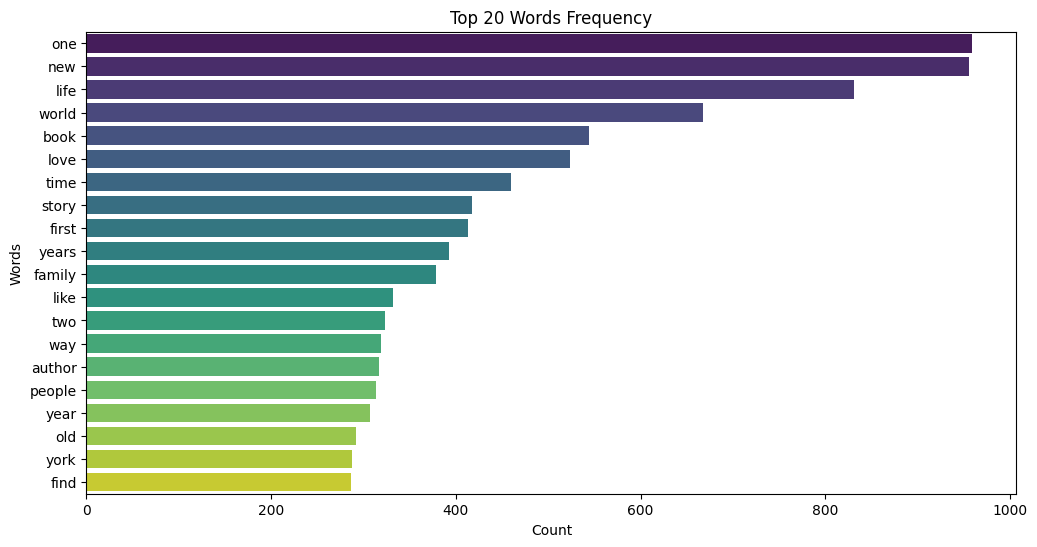

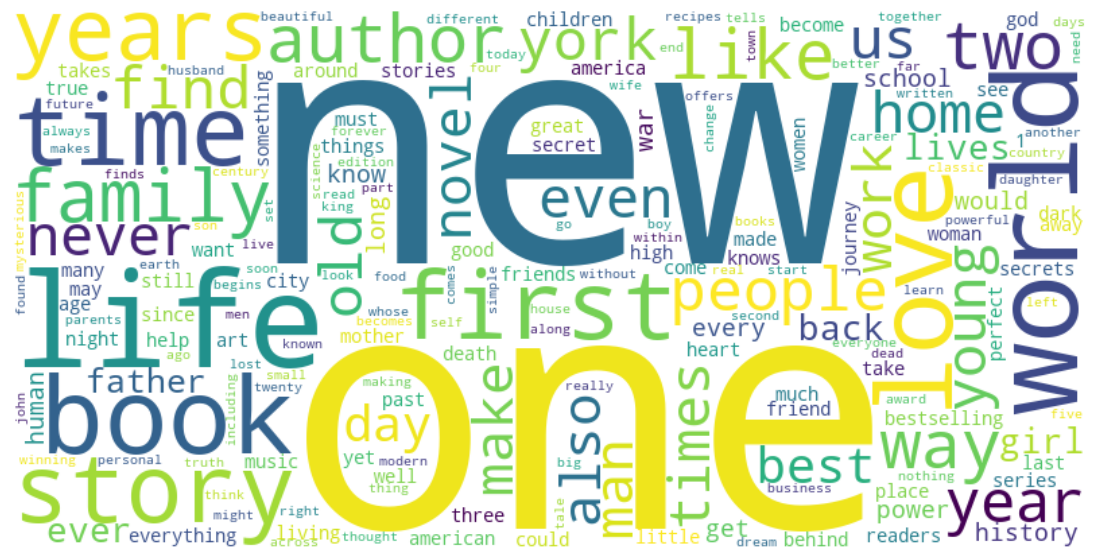

In [23]:
text_data = " ".join(df['Description'].dropna().tolist())
freq_dist = analyze_text(text_data, top_n=20)